In [1]:
import warnings

warnings.filterwarnings("ignore")

In [2]:
import yaml
import pandas as pd

from IPython.display import Image, display

from data_models import Asset
from price_pulse_graph import PricePulseGraph, OverallPricePulseState

In [3]:
from dotenv import load_dotenv

if load_dotenv():
    print("Environment variables loaded.")
else:
    print("No .env file found or failed to load.")

Environment variables loaded.


In [4]:
# Read assets from a YAML file

with open("../data/assets.yml", "r") as file:
    assets = yaml.safe_load(file)

print(assets)

{'asset_001': {'asset': '24K-999 Gold', 'description': 'Pure 24K gold bar for investment purposes', 'asset_class': 'Precious Metals', 'industry': 'Commodities', 'market': 'Global', 'quantity': 10, 'investment_unit': 'gram', 'buy_price_per_unit': 90, 'currency': 'SGD', 'date': '2024-01-15'}, 'asset_002': {'asset': 'Vanguard Information Technology Index Fund VGT ETF', 'description': 'ETF focusing on technology sector stocks', 'asset_class': 'Exchange Traded Funds', 'industry': 'Technology', 'market': 'US', 'quantity': 10, 'investment_unit': 'share', 'buy_price_per_unit': 550, 'currency': 'USD', 'date': '2024-07-15'}, 'asset_003': {'asset': 'CapitaLand Integrated Commercial Trust', 'description': 'REITs focused on commercial properties in Singapore', 'asset_class': 'REITs', 'industry': 'Real Estate', 'market': 'Singapore', 'quantity': 1000, 'investment_unit': 'share', 'buy_price_per_unit': 1.98, 'currency': 'SGD', 'date': '2022-12-15'}, 'asset_004': {'asset': '24K-999 Gold', 'description'

In [5]:
# Prepare a dataframe with input asset information

asset_df = (
    pd.DataFrame.from_dict(assets, orient="index")
    .reset_index()
    .rename(columns={"index": "asset_id"})
)

print(asset_df.shape)
asset_df.head()

(4, 11)


,asset_id,asset,description,asset_class,industry,market,quantity,investment_unit,buy_price_per_unit,currency,date
0,asset_001,24K-999 Gold,Pure 24K gold bar for investment purposes,Precious Metals,Commodities,Global,10,gram,90.00,SGD,2024-01-15
1,asset_002,Vanguard Information Technology Index Fund VGT...,ETF focusing on technology sector stocks,Exchange Traded Funds,Technology,US,10,share,550.00,USD,2024-07-15
2,asset_003,CapitaLand Integrated Commercial Trust,REITs focused on commercial properties in Sing...,REITs,Real Estate,Singapore,1000,share,1.98,SGD,2022-12-15
3,asset_004,24K-999 Gold,Pure 24K gold bar for investment purposes,Precious Metals,Commodities,Global,50,gram,180.00,SGD,2025-12-15


In [6]:
# Load unique assets to gather current price

sel_cols = [
    "asset",
    "description",
    "asset_class",
    "industry",
    "market",
    "investment_unit",
    "currency",
]
unique_assets = asset_df.drop_duplicates(subset=sel_cols, keep="first").reset_index(
    drop=True
)
unique_assets = unique_assets[sel_cols]

print(unique_assets.shape)
unique_assets.head()

(3, 7)


,asset,description,asset_class,industry,market,investment_unit,currency
0,24K-999 Gold,Pure 24K gold bar for investment purposes,Precious Metals,Commodities,Global,gram,SGD
1,Vanguard Information Technology Index Fund VGT...,ETF focusing on technology sector stocks,Exchange Traded Funds,Technology,US,share,USD
2,CapitaLand Integrated Commercial Trust,REITs focused on commercial properties in Sing...,REITs,Real Estate,Singapore,share,SGD


In [7]:
# Load inputs for the agent

asset_list = []
for row in unique_assets.to_dict(orient="records"):
    try:
        asset_list.append(Asset(**row))
    except TypeError:
        asset_list.append(row)

print(f"Loaded {len(asset_list)} assets for price pulse analysis.")

Loaded 3 assets for price pulse analysis.


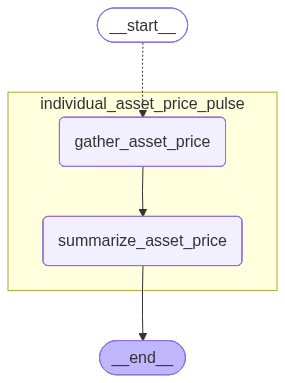

In [8]:
# Load the agent for collecting asset price information
price_pulse_graph = PricePulseGraph().contruct_graph().compile()

# Image(price_pulse_graph.get_graph().draw_png())
display(Image(price_pulse_graph.get_graph(xray=True).draw_mermaid_png()))

In [9]:
# Run the agent to get price pulse information

state = OverallPricePulseState(assets=asset_list)
result = None

thread = {"configurable": {"thread_id": "1"}}

for chunk in price_pulse_graph.stream(state, thread=thread, stream_mode="values"):
    print("\n\nNew Chunk Received:\n")
    if "messages" in chunk:
        for m in chunk["messages"]:
            m.pretty_print()
    if "asset_prices" in chunk:
        print("\n\nCompiled Asset Price Information:")
        print(chunk["asset_prices"])
        result = chunk["asset_prices"]



New Chunk Received:



Compiled Asset Price Information:
[]


New Chunk Received:



Compiled Asset Price Information:
[AssetPriceInfo(asset='24K-999 Gold', description='Pure 24K gold bar for investment purposes', asset_class='Precious Metals', industry='Commodities', market='Global', investment_unit='gram', currency='SGD', current_unit_price=266.0, price_source=['https://www.starlightjewellery.com.sg/pages/gold-prices?srsltid=AfmBOorJDMefXLX4b0c0MOGZj-EkQOrkT6w_RmaKxOP7G1nOOjvlqBO3', 'https://goldpricez.com/sg', 'https://bestgoldshop.asia/?srsltid=AfmBOoqvP1Y0glZ9jJjkXVzArzqebX5jw0xbA-XgmqMaF23aUMt_fPY-']), AssetPriceInfo(asset='Vanguard Information Technology Index Fund VGT ETF', description='ETF focusing on technology sector stocks', asset_class='Exchange Traded Funds', industry='Technology', market='US', investment_unit='share', currency='USD', current_unit_price=730.93, price_source=['https://www.indmoney.com/us-stocks/etf/vgt/vanguard-group-inc-share-price', 'https://www.google

In [10]:
# Parse the results and update the unique_assets dataframe

unique_assets["current_unit_price"] = -1
unique_assets["price_sources"] = "NA"

for asset_price in result:
    unique_assets.loc[
        unique_assets["asset"] == asset_price.asset, "current_unit_price"
    ] = asset_price.current_unit_price
    unique_assets.loc[unique_assets["asset"] == asset_price.asset, "price_sources"] = (
        ", ".join(asset_price.price_source)
    )

print(unique_assets.shape)
unique_assets.head()

(3, 9)


,asset,description,asset_class,industry,market,investment_unit,currency,current_unit_price,price_sources
0,24K-999 Gold,Pure 24K gold bar for investment purposes,Precious Metals,Commodities,Global,gram,SGD,266.00,https://www.starlightjewellery.com.sg/pages/go...
1,Vanguard Information Technology Index Fund VGT...,ETF focusing on technology sector stocks,Exchange Traded Funds,Technology,US,share,USD,730.93,https://www.indmoney.com/us-stocks/etf/vgt/van...
2,CapitaLand Integrated Commercial Trust,REITs focused on commercial properties in Sing...,REITs,Real Estate,Singapore,share,SGD,2.42,Morningstar - https://www.morningstar.com/stoc...
